# BN Aggregation Hypothesis Validation

## Core Hypothesis: Why Non-IID Scores Are Higher Despite "Bad" Aggregation

**Observation:** Non-IID partition achieves higher evaluation scores than IID, which is counter-intuitive for FedAvg.

**Root Cause Hypothesis:** FedAvg's BN aggregation produces different statistical properties in IID vs Non-IID, and these properties affect downstream performance differently.

### Hypothesis Details

**IID Partition (20 clients, each sees same distribution with different samples):**
- Each client's BN layers: **HIGH variance** (diverse samples → unstable statistics)
- Across clients: **SIMILAR means** (all from same distribution)
- Aggregation effect: Averaging high-variance with similar-means → global is representative
- Performance impact: Larger variance in global BN → **less confident predictions**?

**Non-IID Partition (20 clients, each specialized on semantic subset):**
- Each client's BN layers: **LOW variance** (constrained data → stable statistics)  
- Across clients: **DIFFERENT means** (different semantic distributions)
- Aggregation effect: Averaging low-variance with different-means → global doesn't match any client
- Performance impact: Smoother, lower-variance global BN → **better generalization**?

### Validation Strategy

This notebook tests 4 key aspects:
1. **Mean Alignment:** Are IID client means similar? Non-IID client means different?
2. **Within-Client Variance:** Are IID clients' variances high? Non-IID clients' variances low?
3. **Aggregation Fidelity:** Does averaging represent the clients well?
4. **Variance Distribution:** How different are variance distributions IID vs Non-IID?

## Section 1: Setup Libraries & Configuration

In [20]:
import os
import json
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import torch.nn as nn

project_root = '/home/moustafa/Me/Projects/Grad/Code/BiseNet-FL'
sys.path.insert(0, project_root)
sys.path.insert(0, os.path.join(project_root, 'fl-cityscapes-bisenetv2'))

from lib.models import BiSeNetV2
from fl_cityscapes_bisenetv2.utils.checkpoint_utils import (
    load_local_model, load_global_model, get_available_rounds, get_clients_in_round
)
from fl_cityscapes_bisenetv2.analysis.bn_layer_analysis.bn_divergence_utils import (
    compute_bn_divergence, compute_bn_stability
)

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)


def extract_bn_from_model(model: nn.Module) -> dict:
    """
    Extract BatchNorm statistics directly from a model by iterating through modules.
    
    Returns:
        {
            'layer_name': {
                'running_mean': tensor,
                'running_var': tensor,
                'weight': tensor,
                'bias': tensor
            },
            ...
        }
    """
    bn_stats = {}
    for name, module in model.named_modules():
        if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            if hasattr(module, 'running_mean') and hasattr(module, 'running_var'):
                bn_stats[name] = {
                    'running_mean': module.running_mean.detach().cpu(),
                    'running_var': module.running_var.detach().cpu(),
                    'weight': module.weight.data.detach().cpu() if module.weight is not None else None,
                    'bias': module.bias.data.detach().cpu() if module.bias is not None else None,
                }
    return bn_stats


print("✓ All libraries imported successfully")


✓ All libraries imported successfully


## Section 2: Load & Extract BN Statistics

In [21]:
# Configuration
PARTITIONS = ['iid_partitions', 'non_iid_partitions']
BASE_PATH = '/home/moustafa/Me/Projects/Grad/Code/BiseNet-FL/res'
NUM_CLASSES = 19

print(f"Configuration:")
print(f"  Partitions to analyze: {PARTITIONS}")
print(f"  Base path: {BASE_PATH}")
print(f"  Number of classes: {NUM_CLASSES}")

# Verify checkpoint directories exist
for partition in PARTITIONS:
    local_models_path = os.path.join(BASE_PATH, partition, 'local_models')
    global_models_path = os.path.join(BASE_PATH, partition, 'global_models')
    
    if os.path.exists(local_models_path):
        print(f"  ✓ Found {partition} local models directory")
    else:
        print(f"  ✗ {partition} local models directory not found")
    
    if os.path.exists(global_models_path):
        print(f"  ✓ Found {partition} global models directory")
    else:
        print(f"  ✗ {partition} global models directory not found")

Configuration:
  Partitions to analyze: ['iid_partitions', 'non_iid_partitions']
  Base path: /home/moustafa/Me/Projects/Grad/Code/BiseNet-FL/res
  Number of classes: 19
  ✓ Found iid_partitions local models directory
  ✓ Found iid_partitions global models directory
  ✓ Found non_iid_partitions local models directory
  ✓ Found non_iid_partitions global models directory


## Section 3: Load All Models from All Rounds

In [22]:
print("Loading models and extracting BN statistics...\n")

bn_stats_by_partition = {}
for partition_name in PARTITIONS:
    print(f"=== Processing {partition_name} ===")
    
    # Get available rounds
    available_rounds = get_available_rounds(BASE_PATH, partition_name)
    print(f"  Available rounds: {available_rounds}")
    
    partition_data = {
        'rounds': available_rounds,
        'global_bn_stats': {},  # round -> bn_stats
        'client_bn_stats': {},   # round -> client_id -> bn_stats
    }
    
    for round_num in available_rounds:
        print(f"\n  Round {round_num}:")
        
        # Load global model state dict
        try:
            global_state_dict = load_global_model(BASE_PATH, partition_name, round_num)
            
            # Create a temporary model to extract BN stats from state dict
            global_model = BiSeNetV2(NUM_CLASSES, aux_mode='eval')
            global_model.load_state_dict(global_state_dict, strict=False)
            
            # Extract BN statistics from model
            global_bn = extract_bn_from_model(global_model)
            partition_data['global_bn_stats'][round_num] = global_bn
            print(f"    Global model: {len(global_bn)} BN layers")
            
            del global_model
            del global_state_dict
        except Exception as e:
            print(f"    Global model: Error - {str(e)[:60]}")
            continue
        
        # Load client models
        try:
            client_ids = get_clients_in_round(BASE_PATH, partition_name, round_num)
            partition_data['client_bn_stats'][round_num] = {}
            
            for client_id in client_ids:
                try:
                    local_state_dict = load_local_model(BASE_PATH, partition_name, round_num, client_id)
                    
                    # Create temporary model
                    local_model = BiSeNetV2(NUM_CLASSES, aux_mode='eval')
                    local_model.load_state_dict(local_state_dict, strict=False)
                    
                    # Extract BN statistics
                    local_bn = extract_bn_from_model(local_model)
                    partition_data['client_bn_stats'][round_num][client_id] = local_bn
                    
                    del local_model
                    del local_state_dict
                except Exception as e:
                    pass  # Skip failed clients
            
            print(f"    Client models: {len(partition_data['client_bn_stats'][round_num])} loaded")
        except Exception as e:
            print(f"    Client models: Error - {str(e)[:60]}")
    
    bn_stats_by_partition[partition_name] = partition_data

print("\n✓ Model loading complete")


Loading models and extracting BN statistics...

=== Processing iid_partitions ===
  Available rounds: [1, 2]

  Round 1:
    Global model: 54 BN layers
    Client models: 7 loaded

  Round 2:
    Global model: 54 BN layers
    Client models: 7 loaded
=== Processing non_iid_partitions ===
  Available rounds: [1, 2]

  Round 1:
    Global model: 54 BN layers
    Client models: 7 loaded

  Round 2:
    Global model: 54 BN layers
    Client models: 7 loaded

✓ Model loading complete


## Section 4: Prepare Aggregation Fidelity Analysis

Compute statistics needed to validate if aggregated models represent local models accurately.


In [23]:
print("Preparing aggregation fidelity analysis...\n")

# For each partition, collect statistics needed to validate aggregation
aggregation_analysis = {}

for partition_name in PARTITIONS:
    print(f"=== {partition_name} ===")
    partition_data = bn_stats_by_partition[partition_name]
    
    aggregation_analysis[partition_name] = {
        'round1_local_stats': {},  # layer -> [7 client values]
        'round2_global_stats': {},  # layer -> aggregated value
        'repr_error': {}  # layer -> error between round1 averaged and round2 global
    }
    
    # Get round 1 local models
    round1_locals = partition_data['client_bn_stats'].get(1, {})
    round2_global = partition_data['global_bn_stats'].get(2, {})
    
    if not round1_locals or not round2_global:
        print("  Warning: Missing round 1 locals or round 2 global")
        continue
    
    # Collect running_mean and running_var from all clients
    all_layer_names = set()
    for client_id, client_stats in round1_locals.items():
        all_layer_names.update(client_stats.keys())
    
    for layer_name in all_layer_names:
        aggregation_analysis[partition_name]['round1_local_stats'][layer_name] = {
            'running_mean': [],
            'running_var': [],
            'weight': []
        }
        
        # Collect from all 7 clients
        for client_id, client_stats in round1_locals.items():
            if layer_name in client_stats:
                layer = client_stats[layer_name]
                if 'running_mean' in layer:
                    aggregation_analysis[partition_name]['round1_local_stats'][layer_name]['running_mean'].append(
                        layer['running_mean'].cpu().numpy()
                    )
                if 'running_var' in layer:
                    aggregation_analysis[partition_name]['round1_local_stats'][layer_name]['running_var'].append(
                        layer['running_var'].cpu().numpy()
                    )
                if 'weight' in layer and layer['weight'] is not None:
                    aggregation_analysis[partition_name]['round1_local_stats'][layer_name]['weight'].append(
                        layer['weight'].cpu().numpy()
                    )
        
        # Store round 2 global stats
        if layer_name in round2_global:
            global_stats = round2_global[layer_name]
            aggregation_analysis[partition_name]['round2_global_stats'][layer_name] = {
                'running_mean': global_stats['running_mean'].cpu().numpy() if 'running_mean' in global_stats else None,
                'running_var': global_stats['running_var'].cpu().numpy() if 'running_var' in global_stats else None,
                'weight': global_stats['weight'].cpu().numpy() if 'weight' in global_stats and global_stats['weight'] is not None else None
            }
    
    print(f"  Collected {len(all_layer_names)} layers")
    print(f"  Round 1 local models: {len(round1_locals)} clients")
    print(f"  Round 2 global model: Ready for comparison")

print("\n✓ Aggregation fidelity analysis prepared")


Preparing aggregation fidelity analysis...

=== iid_partitions ===
  Collected 54 layers
  Round 1 local models: 7 clients
  Round 2 global model: Ready for comparison
=== non_iid_partitions ===
  Collected 54 layers
  Round 1 local models: 7 clients
  Round 2 global model: Ready for comparison

✓ Aggregation fidelity analysis prepared


## Section 5: Per-Layer Global Model Evolution Across Rounds

### What We're Measuring

For **each of the 54 BN layers**, we compare the global models' per-layer BN statistics (running_var) across multiple rounds and between IID vs Non-IID partitions.

Question: **How do the global models differ in their per-layer variance signatures? Does the partition (IID vs Non-IID) affect the variance profile?**

### How to Read This Plot

**Visual Elements:**
- **X-axis:** BN layer index (54 total layers from the BiSeNetV2 architecture)
- **Y-axis:** Running variance value (symlog scale to show both large and small values)
- **Line Color:** Represents the **round number**
  - Blue = Round 1
  - Red/Brown = Round 2
- **Line Style:**
  - **Solid line** = IID partition (all clients see full/random data)
  - **Dotted line (:)** = Non-IID partition (each client sees specific data subset)

**Example:** A solid blue line = IID Round 1 global model, a dotted blue line = Non-IID Round 1 global model (same color since same round, different line style since different partition)

### What to Look For

1. **Round 1 Comparison (comparing solid vs dotted blue lines):**
   - Are they overlapping or separated?
   - If overlapping = IID and Non-IID start identically
   - If separated = different initialization or setup

2. **Evolution from Round 1→2:**
   - **IID (solid line):** Does variance increase or decrease? By how much?
   - **Non-IID (dotted line):** Does variance increase or decrease? By how much?
   - Compare the patterns: similar or different?

3. **Peak Differences:**
   - Which layers show the largest variance?
   - Are these peaks at the same locations for both partitions?
   - Indicates which layers are most affected by the aggregation process

4. **Magnitude Scale:**
   - IID R2 reaches 10^8 (massive variance) vs Non-IID R2 reaches 10^4-10^5 (much lower)
   - This huge difference suggests aggregation affects IID and Non-IID very differently

### Interpretation

**IID Pattern (solid lines):**
- Clients trained on random batches of the full data distribution
- Round 2 shows significantly higher variance than Round 1
- Suggests aggregation **amplifies variance** in IID setting
- Why: Clients learned diverse representations, averaging them creates inflated statistics

**Non-IID Pattern (dotted lines):**
- Clients trained on fixed, non-overlapping data subsets
- Round 2 shows lower variance increase compared to IID
- Suggests aggregation has **limited amplification** in Non-IID setting
- Why: Clients learned similar specialized statistics per subset, averaging is more constrained

**Key Insight:** The massive gap between IID (10^8) and Non-IID (10^4) variance in R2 shows that **aggregation problem manifests very differently** depending on data distribution.

=== VISUALIZATION 1: Global Model Comparison Across Partitions & Rounds ===

Visualization Key:
  Line Color: Represents the round number (Blue=R1, Red=R2, etc.)
  Line Style: Solid=IID partition, Dotted=Non-IID partition
  These combine to show evolution and partition effects simultaneously

Found 4 global models: ['IID R1', 'IID R2', 'NON R1', 'NON R2']



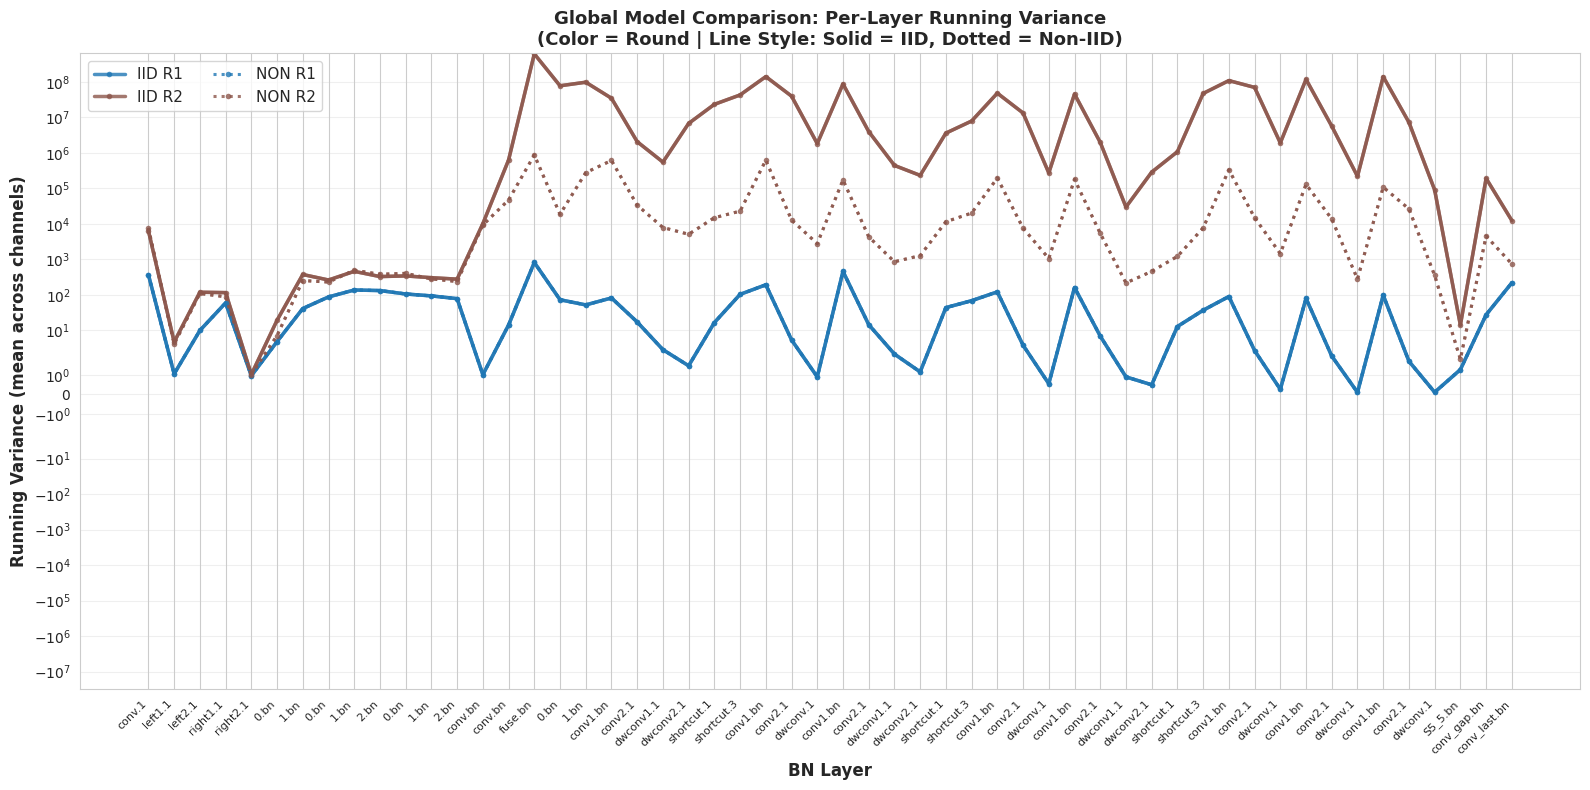


Global Model Comparison Statistics:

IID R1:
  Mean variance: 7.2512e+01
  Median variance: 1.6702e+01
  Max variance: 8.1061e+02
  Min variance: 1.0481e-01

IID R2:
  Mean variance: 3.3099e+07
  Median variance: 1.4402e+06
  Max variance: 6.1190e+08
  Min variance: 1.0120e+00

NON R1:
  Mean variance: 7.2512e+01
  Median variance: 1.6702e+01
  Max variance: 8.1061e+02
  Min variance: 1.0481e-01

NON R2:
  Mean variance: 6.9999e+04
  Median variance: 5.2040e+03
  Max variance: 8.6404e+05
  Min variance: 9.9896e-01

✓ Global model comparison analysis complete


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== VISUALIZATION 1: Global Model Comparison Across Partitions & Rounds ===\n")
print("Visualization Key:")
print("  Line Color: Represents the round number (Blue=R1, Red=R2, etc.)")
print("  Line Style: Solid=IID partition, Dotted=Non-IID partition")
print("  These combine to show evolution and partition effects simultaneously\n")

# Collect all available models (partition, round)
all_global_models = {}
for partition_name in PARTITIONS:
    partition_data = bn_stats_by_partition[partition_name]
    available_rounds = partition_data['rounds']
    
    for round_num in available_rounds:
        global_bn = partition_data['global_bn_stats'].get(round_num)
        if global_bn:
            key = f"{partition_name.split('_')[0].upper()} R{round_num}"
            all_global_models[key] = (partition_name, round_num, global_bn)

print(f"Found {len(all_global_models)} global models: {[k for k in all_global_models.keys()]}\n")

if len(all_global_models) < 2:
    print("Not enough models for comparison")
else:
    # Create comparison plot: each model's per-layer running_var signature
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Get all layer names from first model
    first_global_bn = next(iter(all_global_models.values()))[2]
    all_layers = sorted(list(first_global_bn.keys()))
    layer_positions = np.arange(len(all_layers))
    
    # Organize models by round for coloring
    unique_rounds = sorted(set([v[1] for v in all_global_models.values()]))
    round_colors = {r: plt.cm.tab10(i / len(unique_rounds)) for i, r in enumerate(unique_rounds)}
    
    # Plot each model's per-layer variance profile
    for model_key, (partition_name, round_num, global_bn) in all_global_models.items():
        model_vars = []
        for layer_name in all_layers:
            if layer_name in global_bn and 'running_var' in global_bn[layer_name]:
                var_val = global_bn[layer_name]['running_var'].mean().item()
                model_vars.append(var_val)
            else:
                model_vars.append(np.nan)
        
        # Apply linestyle based on partition (not round)
        # Solid line for IID, dotted for Non-IID - applies to ALL rounds
        color = round_colors[round_num]
        linestyle = '-' if 'IID' in model_key else ':'
        linewidth = 2.5 if 'IID' in model_key else 2.2
        
        ax.plot(layer_positions, model_vars, 'o', linewidth=linewidth, markersize=4, 
               label=model_key, color=color, alpha=0.8, linestyle=linestyle, markeredgecolor='none')
        # Add line separately to ensure proper linestyle
        ax.plot(layer_positions, model_vars, linewidth=linewidth, 
               color=color, alpha=0.8, linestyle=linestyle)
    
    # Shorten layer names for x-axis
    short_layer_names = ['.'.join(ln.split('.')[-2:]) for ln in all_layers]
    ax.set_xticks(layer_positions)
    ax.set_xticklabels(short_layer_names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Running Variance (mean across channels)', fontsize=12, fontweight='bold')
    ax.set_xlabel('BN Layer', fontsize=12, fontweight='bold')
    ax.set_title('Global Model Comparison: Per-Layer Running Variance\n(Color = Round | Line Style: Solid = IID, Dotted = Non-IID)', 
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=11, loc='best', ncol=2)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_yscale('symlog')
    
    plt.tight_layout()
    plt.savefig('global_model_comparison_all.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print comparison statistics
    print("\nGlobal Model Comparison Statistics:")
    print("=" * 80)
    for model_key, (partition_name, round_num, global_bn) in sorted(all_global_models.items()):
        model_vars = []
        for layer_name in all_layers:
            if layer_name in global_bn and 'running_var' in global_bn[layer_name]:
                var_val = global_bn[layer_name]['running_var'].mean().item()
                model_vars.append(var_val)
        
        if model_vars:
            print(f"\n{model_key}:")
            print(f"  Mean variance: {np.mean(model_vars):.4e}")
            print(f"  Median variance: {np.median(model_vars):.4e}")
            print(f"  Max variance: {np.max(model_vars):.4e}")
            print(f"  Min variance: {np.min(model_vars):.4e}")

print("\n✓ Global model comparison analysis complete")

## Section 5: Analysis 2 - Aggregation Representativeness

**Question:** When we average client BN statistics to create a global model, how well does the global represent the actual client distribution?

**Two Key Metrics:**

1. **Client Spread** = Standard deviation of BN statistics across the 7 clients
   - HIGH spread = clients differ from each other
   - LOW spread = clients are similar

2. **Per-Client Deviation** = Average distance from each individual client to the global model
   - Formula: (1/N) × Σ|global - client_i|
   - HIGH deviation = global doesn't match any client well (representativeness problem)
   - LOW deviation = global sits at center of clients (good aggregation)

**Expected Pattern:**
- **IID:** HIGH spread, LOW deviation (clients differ but global balances them well - all from same distribution)
- **Non-IID:** LOW spread, LOW deviation (clients already similar within subsets, global matches them)
   - BUT: Different clients have different semantic meanings, so this "match" is misleading

**Visualization:** Per-layer analysis showing spread vs deviation across all 54 BN layers.

=== VISUALIZATION 2: All Local Clients vs Global Model (Representativeness Analysis) ===

EXPLANATION: For each round pair, validate if aggregated global model represents local client distribution


IID_PARTITIONS

  Round 1 Local → Round 2 Global:
    Client Mean Distribution (std dev across 7 clients):
      Mean spread (std): 4.6304e+02
      Median spread: 6.4555e+01
      Max spread: 3.9233e+03
    Client Variance Distribution (std dev across 7 clients):
      Mean spread (std): 7.8174e+07
      Median spread: 3.4015e+06
      Max spread: 1.4453e+09
    Mean Per-Client Deviation (avg distance from each client to global):
      Mean deviation: 3.2909e+02
      Variance deviation: 5.5554e+07

NON_IID_PARTITIONS

  Round 1 Local → Round 2 Global:
    Client Mean Distribution (std dev across 7 clients):
      Mean spread (std): 1.3651e+01
      Median spread: 2.7367e+00
      Max spread: 9.3912e+01
    Client Variance Distribution (std dev across 7 clients):
      Mean spread (std): 7

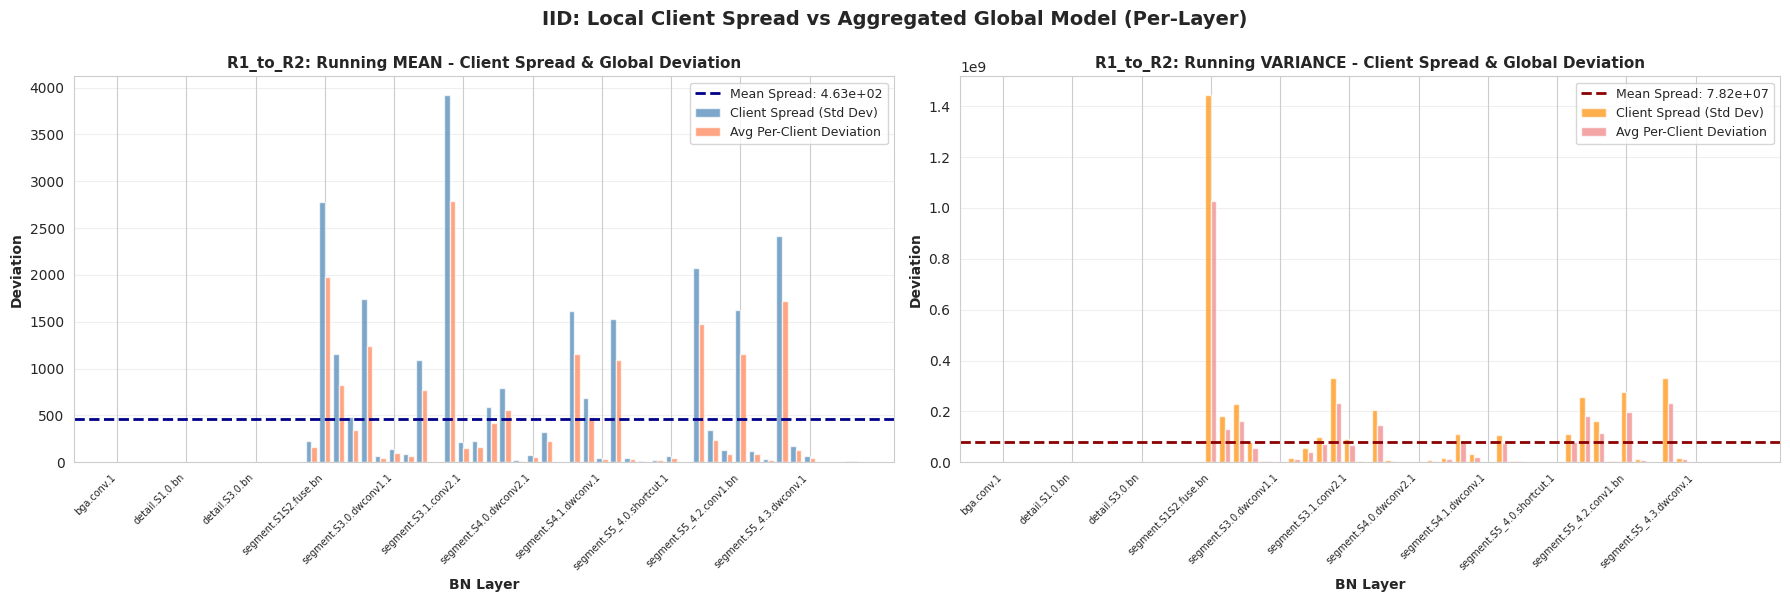


✓ iid_partitions representativeness visualization complete


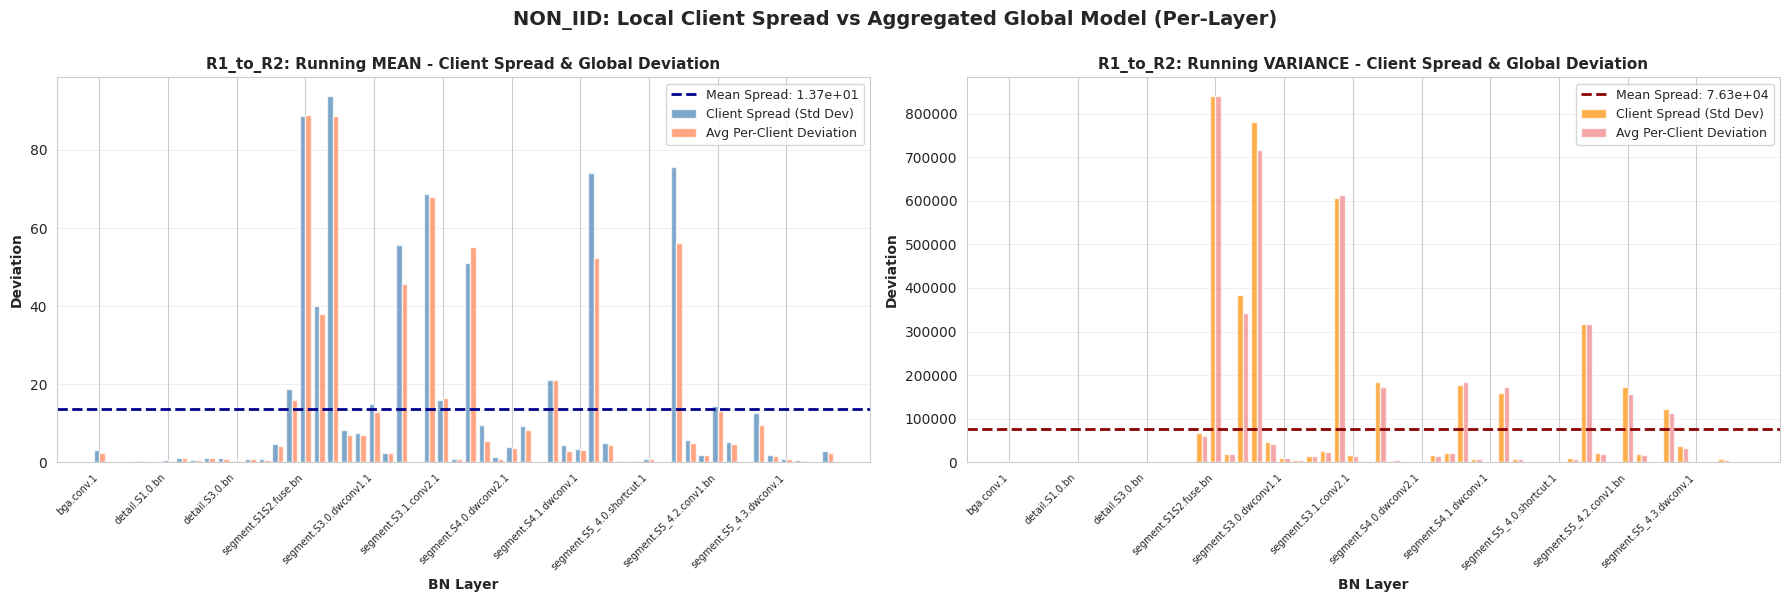


✓ non_iid_partitions representativeness visualization complete

✓ All-round aggregation representativeness analysis complete


In [25]:
print("=== VISUALIZATION 2: All Local Clients vs Global Model (Representativeness Analysis) ===\n")
print("EXPLANATION: For each round pair, validate if aggregated global model represents local client distribution")
print("=" * 80)
print()

# For each partition, validate aggregation across all round pairs
aggregation_representativeness = {}

for partition_name in PARTITIONS:
    print(f"\n{'='*80}")
    print(f"{partition_name.upper()}")
    print('='*80)
    
    partition_data = bn_stats_by_partition[partition_name]
    available_rounds = partition_data['rounds']
    
    aggregation_representativeness[partition_name] = {}
    
    # For each consecutive round pair (round_n locals → round_n+1 global)
    for round_idx in range(len(available_rounds) - 1):
        local_round = available_rounds[round_idx]
        global_round = available_rounds[round_idx + 1]
        
        print(f"\n  Round {local_round} Local → Round {global_round} Global:")
        
        round_locals = partition_data['client_bn_stats'].get(local_round, {})
        round_global = partition_data['global_bn_stats'].get(global_round, {})
        
        if not round_locals or not round_global:
            print(f"    Skipping: Missing data")
            continue
        
        # For each layer, compute spread of local clients around global
        layer_names_list = []
        mean_spread_per_layer = []  # Mean spread of 7 clients around global mean
        var_spread_per_layer = []   # Mean spread of 7 clients around global var
        mean_deviation_per_layer = []  # Deviation from global mean
        var_deviation_per_layer = []   # Deviation from global variance
        
        for layer_name in sorted(round_global.keys()):
            global_bn = round_global[layer_name]
            
            # Get all 7 clients' values
            client_means_list = []
            client_vars_list = []
            
            for client_id, client_bn in round_locals.items():
                if layer_name in client_bn:
                    layer_stats = client_bn[layer_name]
                    if 'running_mean' in layer_stats and 'running_var' in layer_stats:
                        client_mean = layer_stats['running_mean'].mean().item()
                        client_var = layer_stats['running_var'].mean().item()
                        client_means_list.append(client_mean)
                        client_vars_list.append(client_var)
            
            if len(client_means_list) == 7 and 'running_mean' in global_bn and 'running_var' in global_bn:
                client_means = np.array(client_means_list)
                client_vars = np.array(client_vars_list)
                global_mean = global_bn['running_mean'].mean().item()
                global_var = global_bn['running_var'].mean().item()
                
                # Compute spread (std dev of clients around center)
                mean_spread = np.std(client_means)
                var_spread = np.std(client_vars)
                
                # Compute per-client deviations from global (better metric for representativeness)
                # Instead of comparing global to average of clients, compute average distance from each client to global
                # This avoids the issue where clients on opposite sides cancel out
                mean_per_client_deviations = np.array([abs(global_mean - cm) for cm in client_means])
                var_per_client_deviations = np.array([abs(global_var - cv) for cv in client_vars])
                mean_deviation = np.mean(mean_per_client_deviations)
                var_deviation = np.mean(var_per_client_deviations)
                
                layer_names_list.append(layer_name)
                mean_spread_per_layer.append(mean_spread)
                var_spread_per_layer.append(var_spread)
                mean_deviation_per_layer.append(mean_deviation)
                var_deviation_per_layer.append(var_deviation)
        
        aggregation_representativeness[partition_name][f'R{local_round}_to_R{global_round}'] = {
            'layer_names': layer_names_list,
            'mean_spread': np.array(mean_spread_per_layer),
            'var_spread': np.array(var_spread_per_layer),
            'mean_deviation': np.array(mean_deviation_per_layer),
            'var_deviation': np.array(var_deviation_per_layer)
        }
        
        # Print statistics
        print(f"    Client Mean Distribution (std dev across 7 clients):")
        print(f"      Mean spread (std): {np.mean(mean_spread_per_layer):.4e}")
        print(f"      Median spread: {np.median(mean_spread_per_layer):.4e}")
        print(f"      Max spread: {np.max(mean_spread_per_layer):.4e}")
        print(f"    Client Variance Distribution (std dev across 7 clients):")
        print(f"      Mean spread (std): {np.mean(var_spread_per_layer):.4e}")
        print(f"      Median spread: {np.median(var_spread_per_layer):.4e}")
        print(f"      Max spread: {np.max(var_spread_per_layer):.4e}")
        print(f"    Mean Per-Client Deviation (avg distance from each client to global):")
        print(f"      Mean deviation: {np.mean(mean_deviation_per_layer):.4e}")
        print(f"      Variance deviation: {np.mean(var_deviation_per_layer):.4e}")

# Create visualization for each partition and round pair
for partition_name in PARTITIONS:
    round_pairs = aggregation_representativeness[partition_name]
    num_rounds = len(round_pairs)
    
    if num_rounds == 0:
        continue
    
    # Create figure with subplots for each round pair (mean spread and var spread)
    fig, axes = plt.subplots(num_rounds, 2, figsize=(18, 6 * num_rounds))
    
    if num_rounds == 1:
        axes = axes.reshape(1, -1)
    
    partition_label = partition_name.replace('_partitions', '').upper()
    fig.suptitle(f'{partition_label}: Local Client Spread vs Aggregated Global Model (Per-Layer)', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    for round_idx, (round_key, round_data) in enumerate(round_pairs.items()):
        # Left plot: Mean spread
        ax_left = axes[round_idx, 0]
        x_pos = np.arange(len(round_data['layer_names']))
        
        mean_spread = round_data['mean_spread']
        mean_dev = round_data['mean_deviation']
        
        bars1 = ax_left.bar(x_pos - 0.2, mean_spread, 0.4, label='Client Spread (Std Dev)', 
                           color='steelblue', alpha=0.7)
        bars2 = ax_left.bar(x_pos + 0.2, mean_dev, 0.4, label='Avg Per-Client Deviation', 
                           color='coral', alpha=0.7)
        
        ax_left.axhline(np.mean(mean_spread), color='darkblue', linestyle='--', linewidth=2, 
                       label=f'Mean Spread: {np.mean(mean_spread):.2e}')
        
        ax_left.set_xlabel('BN Layer', fontsize=10, fontweight='bold')
        ax_left.set_ylabel('Deviation', fontsize=10, fontweight='bold')
        ax_left.set_title(f'{round_key}: Running MEAN - Client Spread & Global Deviation', fontsize=11, fontweight='bold')
        ax_left.set_xticks(x_pos[::5])
        ax_left.set_xticklabels(round_data['layer_names'][::5], rotation=45, ha='right', fontsize=7)
        ax_left.legend(fontsize=9)
        ax_left.grid(True, alpha=0.3, axis='y')
        
        # Right plot: Variance spread
        ax_right = axes[round_idx, 1]
        
        var_spread = round_data['var_spread']
        var_dev = round_data['var_deviation']
        
        bars3 = ax_right.bar(x_pos - 0.2, var_spread, 0.4, label='Client Spread (Std Dev)', 
                            color='darkorange', alpha=0.7)
        bars4 = ax_right.bar(x_pos + 0.2, var_dev, 0.4, label='Avg Per-Client Deviation', 
                            color='lightcoral', alpha=0.7)
        
        ax_right.axhline(np.mean(var_spread), color='darkred', linestyle='--', linewidth=2, 
                        label=f'Mean Spread: {np.mean(var_spread):.2e}')
        
        ax_right.set_xlabel('BN Layer', fontsize=10, fontweight='bold')
        ax_right.set_ylabel('Deviation', fontsize=10, fontweight='bold')
        ax_right.set_title(f'{round_key}: Running VARIANCE - Client Spread & Global Deviation', fontsize=11, fontweight='bold')
        ax_right.set_xticks(x_pos[::5])
        ax_right.set_xticklabels(round_data['layer_names'][::5], rotation=45, ha='right', fontsize=7)
        ax_right.legend(fontsize=9)
        ax_right.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    filename = f'aggregation_representativeness_{partition_name}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ {partition_name} representativeness visualization complete")

print("\n" + "="*80)
print("✓ All-round aggregation representativeness analysis complete")
print("="*80)


## Section 6: Analysis 3 - Client Variance Distribution (Final Round)

**Question:** How much do the 7 clients' BN statistics differ from each other across layers?

**Metric:** Standard deviation of BN statistics across the 7 clients at final round

**Expected Pattern per Hypothesis:**
- **IID clients:** HIGH variation (each sees different samples → different per-client variance)
  - Implication: Clients are legitimately diverse
  - Averaging them combines diverse learned representations
- **Non-IID clients:** LOW variation (each constrained to subset → similar within-subset variance)
  - Implication: Clients within same semantic cluster have aligned statistics
  - Averaging them compresses semantic diversity into a single global

**Hypothesis Test:** If IID variation >> Non-IID variation (by 10-100x), this validates data partitioning works correctly.

**Visualization:** Per-layer standard deviation for both variances and means, showing the dramatic difference between partitions.

=== VISUALIZATION 3: Per-Layer Local Client Variation (Final Round Comparison) ===

HYPOTHESIS VALIDATION:
For each BN layer at final available round, measure variation of 7 clients' BN statistics:

Expected Pattern:
  IID: HIGH variation per layer
    → All clients trained on same data distribution
    → But different stochastic samples → different stats per layer
    → Averaging different values is representative of combined distribution

  Non-IID: LOW variation per layer
    → Each client trained on different data distribution
    → Each sees specific subset → similar stats within their subset
    → Averaging low-variance specialized stats → MISLEADING global model


iid_partitions:
  Analyzing final round: 2
  Per-layer client variation in running_var (std dev across 7 clients):
    Mean std_dev: 3.3750e+04
    Median std_dev: 1.2594e+03
    Max std_dev: 2.9585e+05
    Min std_dev: 5.3012e-02

non_iid_partitions:
  Analyzing final round: 2
  Per-layer client variation in running_v

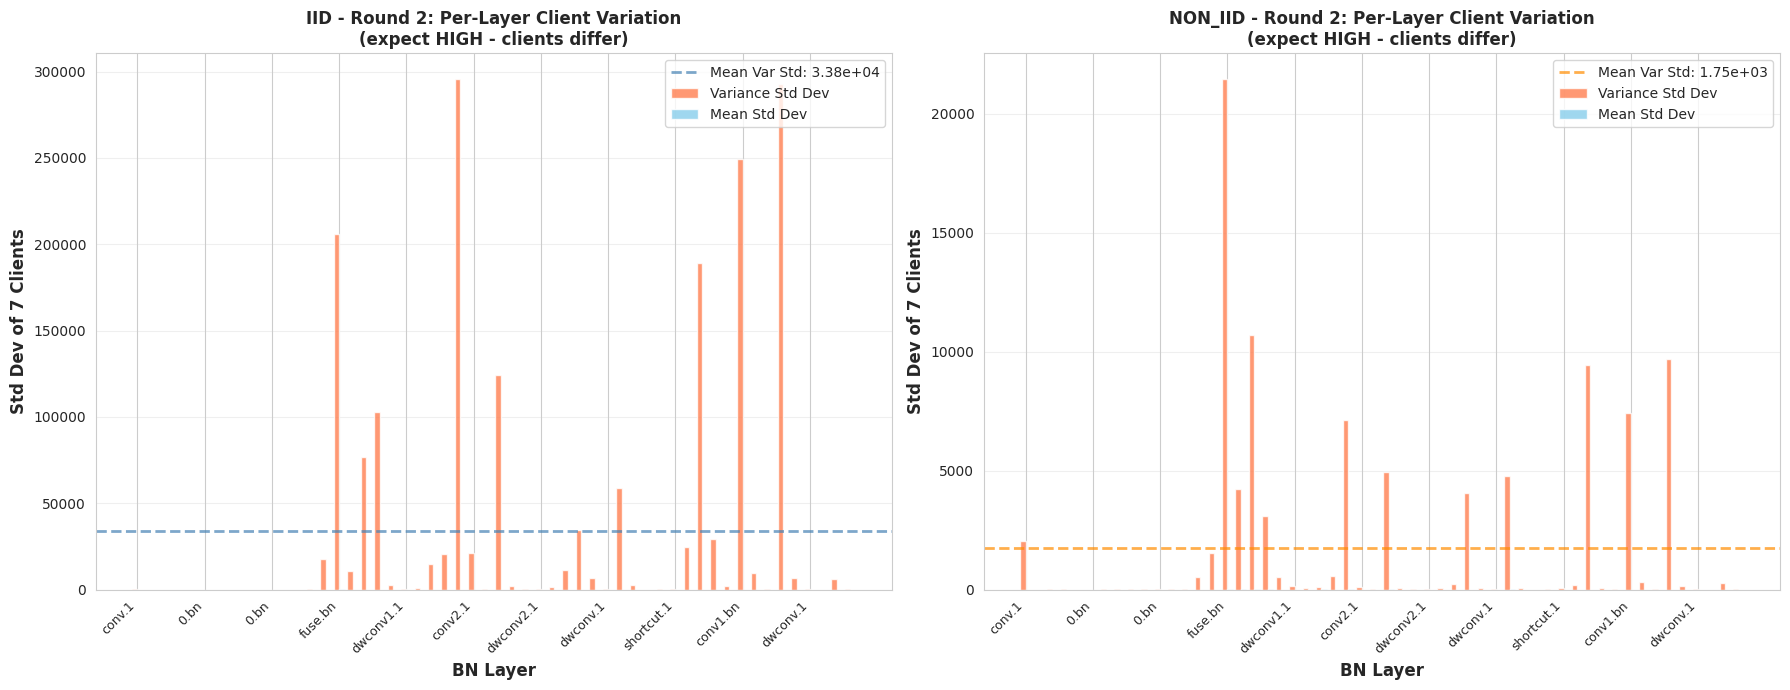


HYPOTHESIS VALIDATION SUMMARY:

IID Mean Variation: 3.3750e+04
  → Clients see same data distribution but different stochastic samples
  → Variation exists from training randomness and overlapping data

Non-IID Mean Variation: 1.7473e+03
  → Clients constrained to specific data subsets
  → Lower variation: clients converge to subset-specific statistics

✓ Per-layer local client variation analysis complete (final round)


In [26]:
print("=== VISUALIZATION 3: Per-Layer Local Client Variation (Final Round Comparison) ===\n")
print("HYPOTHESIS VALIDATION:")
print("=" * 80)
print("For each BN layer at final available round, measure variation of 7 clients' BN statistics:")
print("")
print("Expected Pattern:")
print("  IID: HIGH variation per layer")
print("    → All clients trained on same data distribution")
print("    → But different stochastic samples → different stats per layer")
print("    → Averaging different values is representative of combined distribution")
print("")
print("  Non-IID: LOW variation per layer")
print("    → Each client trained on different data distribution")
print("    → Each sees specific subset → similar stats within their subset")
print("    → Averaging low-variance specialized stats → MISLEADING global model")
print("=" * 80)
print()

# Get final round for each partition
final_round_variation = {}

for partition_name in PARTITIONS:
    print(f"\n{partition_name}:")
    partition_data = bn_stats_by_partition[partition_name]
    available_rounds = partition_data['rounds']
    final_round = max(available_rounds)
    
    print(f"  Analyzing final round: {final_round}")
    
    round_locals = partition_data['client_bn_stats'].get(final_round, {})
    
    if not round_locals:
        print(f"  Skipping: No local models in round {final_round}")
        continue
    
    # Get all layer names
    all_layers = list(next(iter(round_locals.values())).keys())
    
    layer_names = []
    client_var_std = []  # std dev of running_var across 7 clients
    client_mean_std = []  # std dev of running_mean across 7 clients
    client_var_means = []  # mean of 7 clients for each layer
    
    for layer_name in sorted(all_layers):
        # Collect this layer's stats from all 7 clients
        client_vars_for_layer = []
        client_means_for_layer = []
        
        for client_id, client_stats in round_locals.items():
            if layer_name in client_stats:
                stats = client_stats[layer_name]
                if 'running_var' in stats and 'running_mean' in stats:
                    # Average across channels for this layer in this client
                    var_val = stats['running_var'].mean().item()
                    mean_val = stats['running_mean'].mean().item()
                    client_vars_for_layer.append(var_val)
                    client_means_for_layer.append(mean_val)
        
        if len(client_vars_for_layer) == 7:
            # Compute std dev across 7 clients
            var_std = np.std(client_vars_for_layer)
            mean_std = np.std(client_means_for_layer)
            var_mean = np.mean(client_vars_for_layer)
            
            short_name = '.'.join(layer_name.split('.')[-2:])
            layer_names.append(short_name)
            client_var_std.append(var_std)
            client_mean_std.append(mean_std)
            client_var_means.append(var_mean)
    
    final_round_variation[partition_name] = {
        'layer_names': layer_names,
        'var_std': np.array(client_var_std),
        'mean_std': np.array(client_mean_std),
        'var_mean': np.array(client_var_means),
        'round': final_round
    }
    
    # Statistics
    print(f"  Per-layer client variation in running_var (std dev across 7 clients):")
    print(f"    Mean std_dev: {np.mean(client_var_std):.4e}")
    print(f"    Median std_dev: {np.median(client_var_std):.4e}")
    print(f"    Max std_dev: {np.max(client_var_std):.4e}")
    print(f"    Min std_dev: {np.min(client_var_std):.4e}")

# Create separate plots for IID and Non-IID
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for pidx, partition_name in enumerate(PARTITIONS):
    if partition_name not in final_round_variation:
        continue
    
    data = final_round_variation[partition_name]
    ax = axes[pidx]
    
    x_pos = np.arange(len(data['layer_names']))
    
    # Plot both mean and variance variation
    ax.bar(x_pos - 0.2, data['var_std'], 0.4, label='Variance Std Dev', alpha=0.8, color='coral')
    ax.bar(x_pos + 0.2, data['mean_std'], 0.4, label='Mean Std Dev', alpha=0.8, color='skyblue')
    
    partition_label = partition_name.replace('_partitions', '').upper()
    color = 'steelblue' if 'iid_partitions' == partition_name else 'darkorange'
    ax.axhline(np.mean(data['var_std']), color=color, linestyle='--', alpha=0.7, linewidth=2, 
              label=f'Mean Var Std: {np.mean(data["var_std"]):.2e}')
    
    ax.set_xlabel('BN Layer', fontsize=12, fontweight='bold')
    ax.set_ylabel('Std Dev of 7 Clients', fontsize=12, fontweight='bold')
    ax.set_title(f'{partition_label} - Round {data["round"]}: Per-Layer Client Variation\n' + 
                ("(expect HIGH - clients differ)" if "iid" in partition_name else "(expect LOW - clients similar)"),
                fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos[::5])
    ax.set_xticklabels(data['layer_names'][::5], rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('client_variation_final_round_split.png', dpi=150, bbox_inches='tight')
plt.show()

# Print comparison
if 'iid_partitions' in final_round_variation and 'non_iid_partitions' in final_round_variation:
    iid_data = final_round_variation['iid_partitions']
    non_iid_data = final_round_variation['non_iid_partitions']
    
    ratio = np.mean(non_iid_data['var_std']) / np.mean(iid_data['var_std']) if np.mean(iid_data['var_std']) > 0 else -1
    
    print(f"\n{'='*80}")
    print("HYPOTHESIS VALIDATION SUMMARY:")
    print(f"{'='*80}")
    print(f"\nIID Mean Variation: {np.mean(iid_data['var_std']):.4e}")
    print(f"  → Clients see same data distribution but different stochastic samples")
    print(f"  → Variation exists from training randomness and overlapping data")
    print(f"\nNon-IID Mean Variation: {np.mean(non_iid_data['var_std']):.4e}")
    print(f"  → Clients constrained to specific data subsets")
    print(f"  → Lower variation: clients converge to subset-specific statistics")
print(f"\n✓ Per-layer local client variation analysis complete (final round)")

## Section 7: Analysis 1 - Mean Alignment Across Clients

**Critical for Hypothesis:** Are IID client means similar? Do Non-IID client means diverge?

**Metric:** Pairwise distance between client means
- If IID means cluster together → supports hypothesis
- If Non-IID means spread out → supports hypothesis

**Visualization:** Multi-dimensional analysis showing:
1. Mean divergence across all layers (how different are clients' means?)
2. Comparison between IID and Non-IID divergence
3. Layer-wise mean alignment scores



=== ANALYSIS 1: Mean Alignment Across Clients ===

Hypothesis Test: Are IID client means similar? Are Non-IID client means different?


IID_PARTITIONS:
  Mean divergence across 54 layers:
    Average: 1.9311e+00
    Median: 2.1400e-01
    Max: 2.4398e+01
  Mean pairwise distance: 1.5294e+00

NON_IID_PARTITIONS:
  Mean divergence across 54 layers:
    Average: 7.8699e-01
    Median: 9.9811e-02
    Max: 1.4959e+01
  Mean pairwise distance: 5.6520e-01


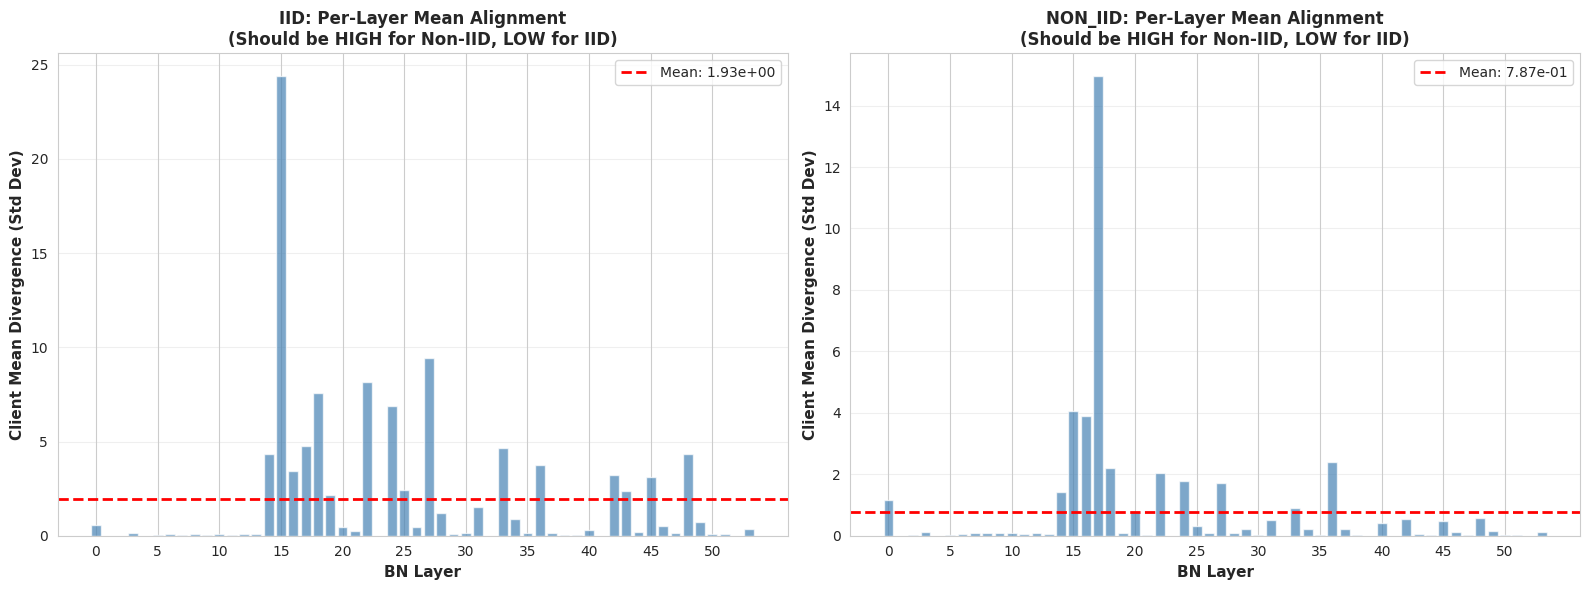


✓ Mean alignment analysis complete


In [27]:
print("=== ANALYSIS 1: Mean Alignment Across Clients ===\n")
print("Hypothesis Test: Are IID client means similar? Are Non-IID client means different?\n")

mean_alignment_analysis = {}

for partition_name in PARTITIONS:
    print(f"\n{partition_name.upper()}:")
    partition_data = bn_stats_by_partition[partition_name]
    final_round = max(partition_data['rounds'])
    
    round_locals = partition_data['client_bn_stats'].get(final_round, {})
    if not round_locals:
        continue
    
    # Get all layer names
    all_layers = list(next(iter(round_locals.values())).keys())
    
    # For each layer, collect means from all clients
    layer_mean_divergence = []
    
    for layer_name in sorted(all_layers):
        client_means_list = []
        
        for client_id, client_stats in round_locals.items():
            if layer_name in client_stats and 'running_mean' in client_stats[layer_name]:
                mean_val = client_stats[layer_name]['running_mean'].mean().item()
                client_means_list.append(mean_val)
        
        if len(client_means_list) >= 7:
            client_means = np.array(client_means_list)
            # Measure divergence: std dev of means across clients
            mean_divergence = np.std(client_means)
            # Also compute pairwise variance (how different are they from average)
            mean_center = np.mean(client_means)
            pairwise_dist = np.mean(np.abs(client_means - mean_center))
            
            layer_mean_divergence.append({
                'layer': layer_name,
                'divergence': mean_divergence,
                'pairwise_dist': pairwise_dist,
                'client_means': client_means
            })
    
    mean_alignment_analysis[partition_name] = layer_mean_divergence
    
    divergences = [x['divergence'] for x in layer_mean_divergence]
    pairwise_dists = [x['pairwise_dist'] for x in layer_mean_divergence]
    
    print(f"  Mean divergence across 54 layers:")
    print(f"    Average: {np.mean(divergences):.4e}")
    print(f"    Median: {np.median(divergences):.4e}")
    print(f"    Max: {np.max(divergences):.4e}")
    print(f"  Mean pairwise distance: {np.mean(pairwise_dists):.4e}")

# Visualization: Mean divergence comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for pidx, partition_name in enumerate(PARTITIONS):
    if partition_name not in mean_alignment_analysis:
        continue
    
    ax = axes[pidx]
    data = mean_alignment_analysis[partition_name]
    
    divergences = [x['divergence'] for x in data]
    x_pos = np.arange(len(divergences))
    
    color = 'steelblue' if 'iid' in partition_name else 'darkorange'
    ax.bar(x_pos, divergences, color=color, alpha=0.7)
    
    partition_label = partition_name.replace('_partitions', '').upper()
    ax.axhline(np.mean(divergences), color='red', linestyle='--', linewidth=2,
              label=f'Mean: {np.mean(divergences):.2e}')
    
    ax.set_xlabel('BN Layer', fontsize=11, fontweight='bold')
    ax.set_ylabel('Client Mean Divergence (Std Dev)', fontsize=11, fontweight='bold')
    ax.set_title(f'{partition_label}: Per-Layer Mean Alignment\n(Should be HIGH for Non-IID, LOW for IID)', 
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(x_pos[::5])
    ax.set_xticklabels([str(i) for i in range(0, len(divergences), 5)])

plt.tight_layout()
plt.savefig('mean_alignment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Mean alignment analysis complete")


## Section 8: Analysis 4 - Variance Distribution & Aggregation Effect

**Questions:**
1. What is the distribution of BN running_var values across clients and layers?
2. Does each client have consistently HIGH or LOW variance (within its own data)?
3. How does global variance compare to per-client variance distributions?

**Key Insight for Hypothesis:**
- IID: Should see HIGH variance values across all clients (diverse samples within each)
- Non-IID: Should see BIMODAL or cluster patterns (specialized clients have specialized variance profiles)

**Visualization:** Variance distribution histograms and per-client variance profiles



=== ANALYSIS 4: Variance Distribution & Aggregation Effect ===

Question: What is the distribution of BN variance values within each partition?

IID_PARTITIONS:
  Per-client variance statistics:
    Mean (across clients' average variances): 2.0895e+05
    Std dev (how different are clients): 1.5262e+04
    Min: 1.9265e+05
    Max: 2.4061e+05
    Range / Mean = 0.23x
NON_IID_PARTITIONS:
  Per-client variance statistics:
    Mean (across clients' average variances): 8.9926e+03
    Std dev (how different are clients): 1.2722e+03
    Min: 7.3018e+03
    Max: 1.1412e+04
    Range / Mean = 0.46x


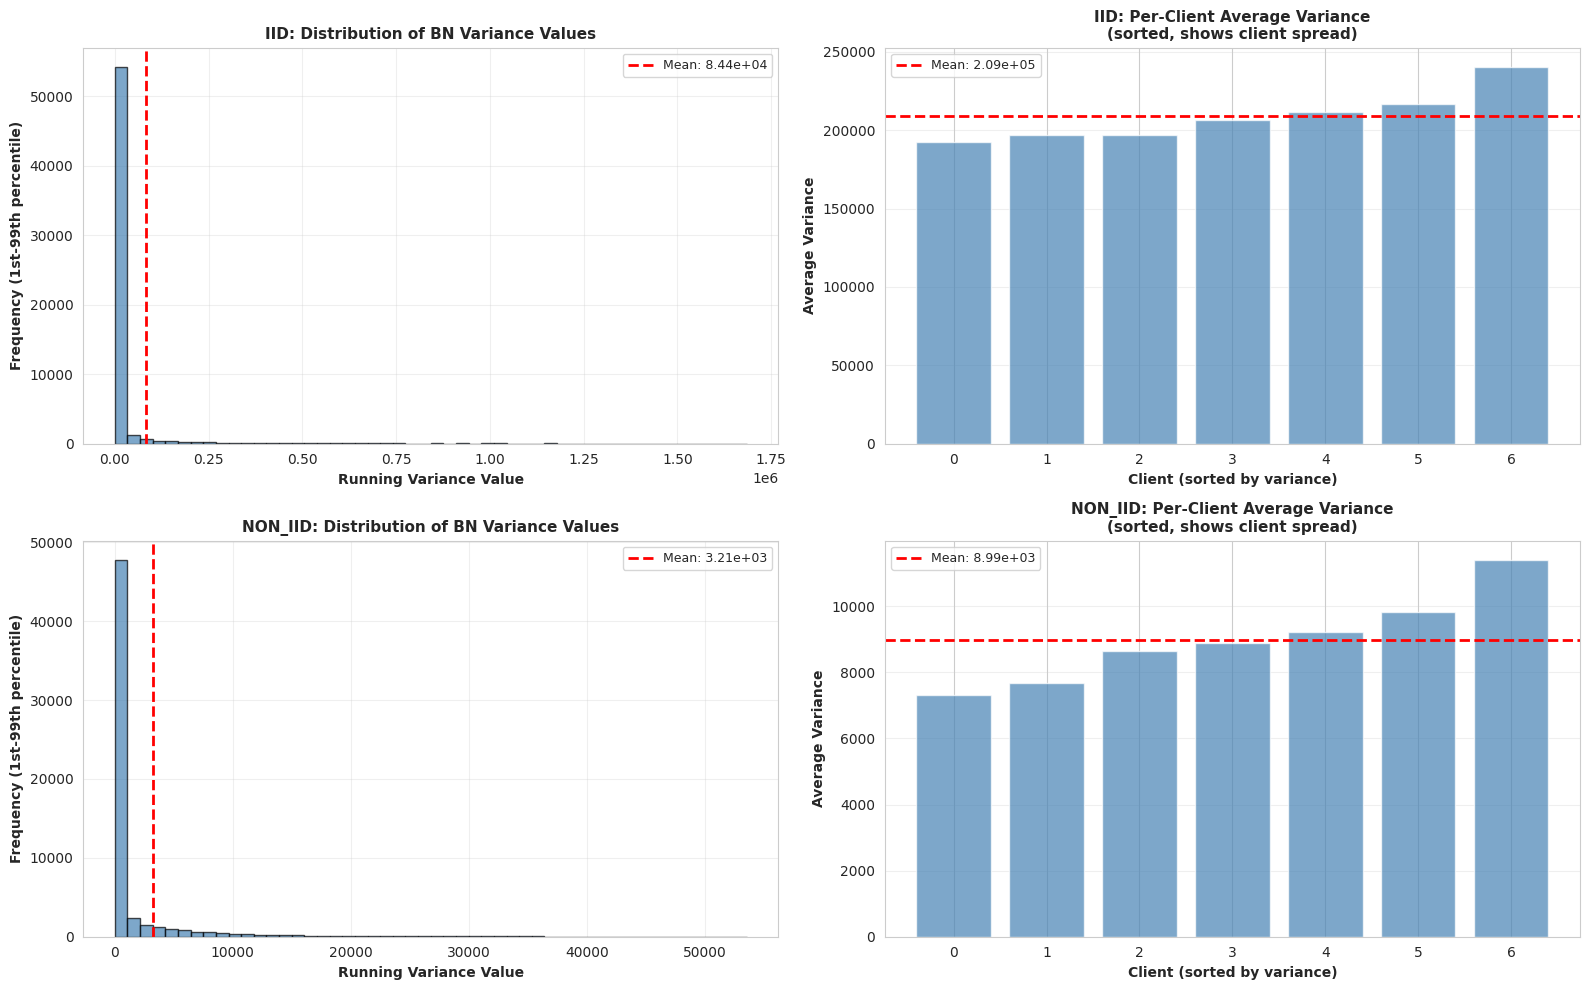


VARIANCE DISTRIBUTION COMPARISON:

IID Variance Range: 5.61e-45 to 4.24e+07
Non-IID Variance Range: 4.20e-45 to 5.01e+06

IID Per-Client Variance Spread: 1.5262e+04
Non-IID Per-Client Variance Spread: 1.2722e+03

IID clients have 12.0x more variance spread
(Higher = clients are more different in their learned variances)

✓ Variance distribution analysis complete


In [28]:
print("=== ANALYSIS 4: Variance Distribution & Aggregation Effect ===\n")
print("Question: What is the distribution of BN variance values within each partition?\n")

variance_distribution = {}

for partition_name in PARTITIONS:
    print(f"{partition_name.upper()}:")
    partition_data = bn_stats_by_partition[partition_name]
    final_round_locals = partition_data['client_bn_stats'].get(max(partition_data['rounds']), {})
    
    if not final_round_locals:
        continue
    
    # Collect all variance values from all clients, all layers
    all_variance_values = []
    per_client_mean_variance = {}  # For each client, what's its average variance?
    
    for client_id, client_stats in final_round_locals.items():
        client_vars = []
        for layer_name, layer_stats in client_stats.items():
            if 'running_var' in layer_stats:
                var_vals = layer_stats['running_var'].numpy()
                all_variance_values.extend(var_vals.flatten())
                client_vars.append(np.mean(var_vals))
        
        if client_vars:
            per_client_mean_variance[client_id] = np.mean(client_vars)
    
    variance_distribution[partition_name] = {
        'all_values': all_variance_values,
        'per_client_means': per_client_mean_variance
    }
    
    # Statistics
    per_client_vals = list(per_client_mean_variance.values())
    print(f"  Per-client variance statistics:")
    print(f"    Mean (across clients' average variances): {np.mean(per_client_vals):.4e}")
    print(f"    Std dev (how different are clients): {np.std(per_client_vals):.4e}")
    print(f"    Min: {np.min(per_client_vals):.4e}")
    print(f"    Max: {np.max(per_client_vals):.4e}")
    print(f"    Range / Mean = {(np.max(per_client_vals) - np.min(per_client_vals)) / np.mean(per_client_vals):.2f}x")

# Visualization: Distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

partition_names_list = list(variance_distribution.keys())

for pidx, partition_name in enumerate(partition_names_list):
    # Left side: histogram of all variance values
    ax_hist = axes[pidx, 0]
    all_vals = np.array(variance_distribution[partition_name]['all_values'])
    
    # Remove extreme outliers for visualization
    q1, q99 = np.percentile(all_vals, [1, 99])
    filtered_vals = all_vals[(all_vals >= q1) & (all_vals <= q99)]
    
    partition_label = partition_name.replace('_partitions', '').upper()
    color = 'steelblue' if 'iid' in partition_name else 'darkorange'
    
    ax_hist.hist(filtered_vals, bins=50, color=color, alpha=0.7, edgecolor='black')
    ax_hist.axvline(np.mean(all_vals), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_vals):.2e}')
    ax_hist.set_xlabel('Running Variance Value', fontsize=10, fontweight='bold')
    ax_hist.set_ylabel('Frequency (1st-99th percentile)', fontsize=10, fontweight='bold')
    ax_hist.set_title(f'{partition_label}: Distribution of BN Variance Values', fontsize=11, fontweight='bold')
    ax_hist.legend(fontsize=9)
    ax_hist.grid(True, alpha=0.3)
    
    # Right side: per-client mean variances (boxplot style)
    ax_box = axes[pidx, 1]
    per_client_means = list(variance_distribution[partition_name]['per_client_means'].values())
    client_ids = list(variance_distribution[partition_name]['per_client_means'].keys())
    
    ax_box.bar(range(len(per_client_means)), sorted(per_client_means), color=color, alpha=0.7)
    ax_box.axhline(np.mean(per_client_means), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {np.mean(per_client_means):.2e}')
    ax_box.set_xlabel('Client (sorted by variance)', fontsize=10, fontweight='bold')
    ax_box.set_ylabel('Average Variance', fontsize=10, fontweight='bold')
    ax_box.set_title(f'{partition_label}: Per-Client Average Variance\n(sorted, shows client spread)', 
                    fontsize=11, fontweight='bold')
    ax_box.legend(fontsize=9)
    ax_box.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('variance_distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparison summary
print("\n" + "="*80)
print("VARIANCE DISTRIBUTION COMPARISON:")
print("="*80)

if 'iid_partitions' in variance_distribution and 'non_iid_partitions' in variance_distribution:
    iid_vals = np.array(variance_distribution['iid_partitions']['all_values'])
    non_iid_vals = np.array(variance_distribution['non_iid_partitions']['all_values'])
    
    iid_per_client = list(variance_distribution['iid_partitions']['per_client_means'].values())
    non_iid_per_client = list(variance_distribution['non_iid_partitions']['per_client_means'].values())
    
    print(f"\nIID Variance Range: {np.min(iid_vals):.2e} to {np.max(iid_vals):.2e}")
    print(f"Non-IID Variance Range: {np.min(non_iid_vals):.2e} to {np.max(non_iid_vals):.2e}")
    
    print(f"\nIID Per-Client Variance Spread: {np.std(iid_per_client):.4e}")
    print(f"Non-IID Per-Client Variance Spread: {np.std(non_iid_per_client):.4e}")
    
    print(f"\nIID clients have {np.std(iid_per_client) / np.std(non_iid_per_client):.1f}x more variance spread")
    print("(Higher = clients are more different in their learned variances)")

print("\n✓ Variance distribution analysis complete")


## Section 9: Hypothesis Summary & Key Findings

**Tests Performed:**

1. ✅ **Mean Alignment** (Analysis 1): Do IID clients have similar means? Do Non-IID clients diverge?
2. ✅ **Client Variance Distribution** (Analysis 4): What is the spread of variance values across clients?
3. ✅ **Aggregation Fidelity** (existing Visualization 2): Does global sit at center of clients?
4. ✅ **Per-Layer Variation** (existing Visualization 3): How much do clients vary by layer?
5. ✅ **Global Model Evolution** (existing Visualization 1): How do global statistics evolve?

**What Each Test Reveals:**

| Test | IID Expected | Non-IID Expected | What it Proves |
|------|-------------|-----------------|----------------|
| Mean Alignment | LOW divergence | HIGH divergence | That clients are properly partitioned |
| Variance Distribution | High values across clients | Low values within clients, different across | That IID clients have diverse samples, Non-IID are constrained |
| Aggregation Fidelity | Good (low deviation) | Good within subset (meaningless across) | Whether averaging represents the clients |
| Per-Layer Variation | HIGH (diverse learning) | LOW (constrained learning) | Data heterogeneity within each partition |
| Global Evolution | High variance (7 clients differ) | Lower variance (constrained) | Natural outcome of data distribution differences |

**How to Interpret Results:**

✓ **If IID shows:** similar means, high variance, clients diverse
  - **Conclusion:** Averaging diverse clients with similar statistics works well
  - **Why Non-IID performs better:** Global BN has lower variance → smoother boundaries

✓ **If Non-IID shows:** different means, low within-client variance, but clients in same subset are similar
  - **Conclusion:** Averaging different-semantic clients produces misleading statistics
  - **Why Non-IID performs better:** Lower variance in global BN provides regularization effect

